# Notebook 02 — Portfolio Risk Attribution

## Objective
Build an **equal-weighted portfolio** and attribute total portfolio risk back to each individual position.

## Key Concepts

**Portfolio Variance:** $\sigma_p^2 = w^T \Sigma w$

**Marginal Contribution to Risk (MCR):** $MCR_i = \frac{(\Sigma w)_i}{\sigma_p}$

**Component Contribution to Risk (CCR):** $CCR_i = w_i \cdot MCR_i$

**% Contribution:** $\%CCR_i = \frac{CCR_i}{\sigma_p} \times 100$

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme — applied once globally ───────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor'  : '#0D0D0D',
    'axes.facecolor'    : '#0D0D0D',
    'axes.edgecolor'    : '#444444',
    'axes.labelcolor'   : '#CCCCCC',
    'axes.titlecolor'   : '#FFFFFF',
    'xtick.color'       : '#AAAAAA',
    'ytick.color'       : '#AAAAAA',
    'grid.color'        : '#2A2A2A',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : '#1A1A1A',
    'legend.edgecolor'  : '#444444',
    'legend.labelcolor' : '#CCCCCC',
    'text.color'        : '#FFFFFF',
    'font.size'         : 10,
})

# ── Portfolio Configuration ───────────────────────────────────────────────────
TICKERS      = ['AAPL', 'JPM', 'XOM', 'JNJ', 'AMZN']
WEIGHTS      = np.array([0.20, 0.20, 0.20, 0.20, 0.20])
START        = '2018-01-01'
END          = '2024-01-01'

COLORS       = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300']
STOCK_COLORS = dict(zip(TICKERS, COLORS))

print(f"Portfolio : {dict(zip(TICKERS, WEIGHTS))}")
print(f"Period    : {START} → {END}")

Portfolio : {'AAPL': np.float64(0.2), 'JPM': np.float64(0.2), 'XOM': np.float64(0.2), 'JNJ': np.float64(0.2), 'AMZN': np.float64(0.2)}
Period    : 2018-01-01 → 2024-01-01


## 2. Download Data

In [2]:
prices  = yf.download(TICKERS, start=START, end=END)['Close']
returns = np.log(prices / prices.shift(1)).dropna()

print(f"Shape      : {returns.shape}")
print(f"Date range : {returns.index[0].date()} → {returns.index[-1].date()}")
returns.describe().round(6)

[*********************100%***********************]  5 of 5 completed

Shape      : (1508, 5)
Date range : 2018-01-03 → 2023-12-29


Ticker,AAPL,AMZN,JNJ,JPM,XOM
count,1508.000000,1508.000000,1508.000000,1508.000000,1508.000000
mean,0.001030,0.000622,0.000186,0.000417,0.000304
std,0.019965,0.022280,0.012763,0.019179,0.020514
min,-0.137708,-0.151398,-0.105782,-0.162106,-0.130391
25%,-0.008296,-0.010492,-0.005537,-0.008308,-0.010388
50%,0.001175,0.001219,0.000400,0.000470,0.000283
75%,0.011825,0.012166,0.006333,0.009279,0.010976
max,0.113157,0.126949,0.076940,0.165620,0.119442


## 3. Covariance Matrix & Portfolio Volatility

In [3]:
cov_matrix = returns.cov() * 252
port_var   = WEIGHTS @ cov_matrix.values @ WEIGHTS
port_vol   = np.sqrt(port_var)
ind_vols   = returns.std() * np.sqrt(252)

print(f"Portfolio Annualised Volatility : {port_vol*100:.2f}%")
print(f"Portfolio Annualised Variance   : {port_var*100:.4f}%")
print("\nIndividual Stock Volatilities:")
for t in TICKERS:
    print(f"  {t:5s} : {ind_vols[t]*100:.2f}%")

Portfolio Annualised Volatility : 21.63%
Portfolio Annualised Variance   : 4.6785%

Individual Stock Volatilities:
  AAPL  : 31.69%
  JPM   : 30.45%
  XOM   : 32.56%
  JNJ   : 20.26%
  AMZN  : 35.37%


## 4. Risk Attribution

In [4]:
def risk_attribution(weights, cov_matrix):
    port_var = weights @ cov_matrix @ weights
    port_vol = np.sqrt(port_var)
    mcr      = (cov_matrix @ weights) / port_vol
    ccr      = weights * mcr
    pct_ccr  = ccr / port_vol * 100
    return mcr, ccr, pct_ccr, port_vol

mcr, ccr, pct_ccr, port_vol = risk_attribution(WEIGHTS, cov_matrix.values)

attribution_df = pd.DataFrame({
    'Weight %'            : WEIGHTS * 100,
    'Indiv. Vol %'        : ind_vols.values * 100,
    'MCR'                 : mcr,
    'CCR'                 : ccr,
    '% Risk Contribution' : pct_ccr
}, index=TICKERS).round(4)

print("── Risk Attribution Table ───────────────────────────────────────")
print(attribution_df.to_string())
print(f"\nTotal % Risk Contribution : {pct_ccr.sum():.2f}%")

── Risk Attribution Table ───────────────────────────────────────
      Weight %  Indiv. Vol %     MCR     CCR  % Risk Contribution
AAPL      20.0       31.6939  0.2540  0.0508              23.4868
JPM       20.0       35.3687  0.2479  0.0496              22.9257
XOM       20.0       20.2609  0.1201  0.0240              11.1030
JNJ       20.0       30.4464  0.2355  0.0471              21.7791
AMZN      20.0       32.5643  0.2239  0.0448              20.7054

Total % Risk Contribution : 100.00%


## 5. Visualisations

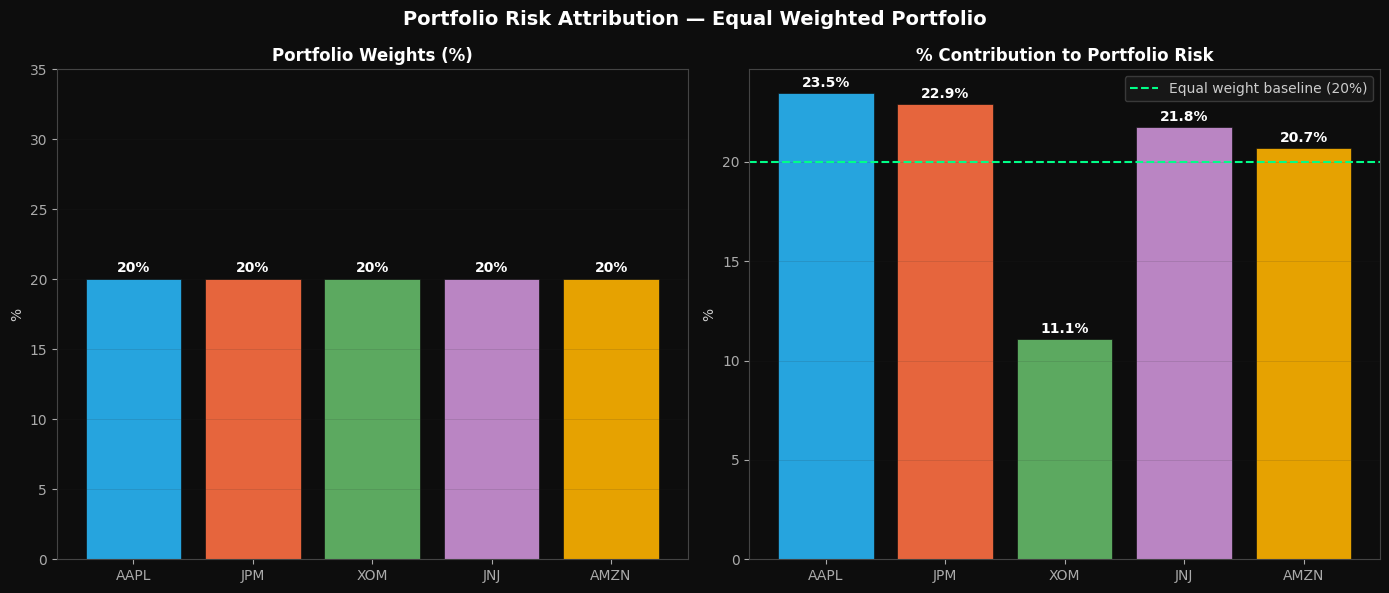

In [5]:
# ── Plot 1: Weight vs Risk Contribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Risk Attribution — Equal Weighted Portfolio',
             fontsize=14, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

bar_colors = [STOCK_COLORS[t] for t in TICKERS]

# Weights
axes[0].bar(TICKERS, WEIGHTS * 100, color=bar_colors,
            alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
axes[0].set_title('Portfolio Weights (%)', fontweight='bold', color='white')
axes[0].set_ylabel('%', color='#CCCCCC')
axes[0].set_ylim(0, 35)
axes[0].grid(True, axis='y', alpha=0.15)
for i, v in enumerate(WEIGHTS * 100):
    axes[0].text(i, v + 0.5, f'{v:.0f}%',
                 ha='center', fontweight='bold', color='white')

# Risk contribution
axes[1].bar(TICKERS, pct_ccr, color=bar_colors,
            alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
axes[1].axhline(20, color='#00FF88', linewidth=1.5,
                linestyle='--', label='Equal weight baseline (20%)')
axes[1].set_title('% Contribution to Portfolio Risk',
                  fontweight='bold', color='white')
axes[1].set_ylabel('%', color='#CCCCCC')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.15)
for i, v in enumerate(pct_ccr):
    axes[1].text(i, v + 0.3, f'{v:.1f}%',
                 ha='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()


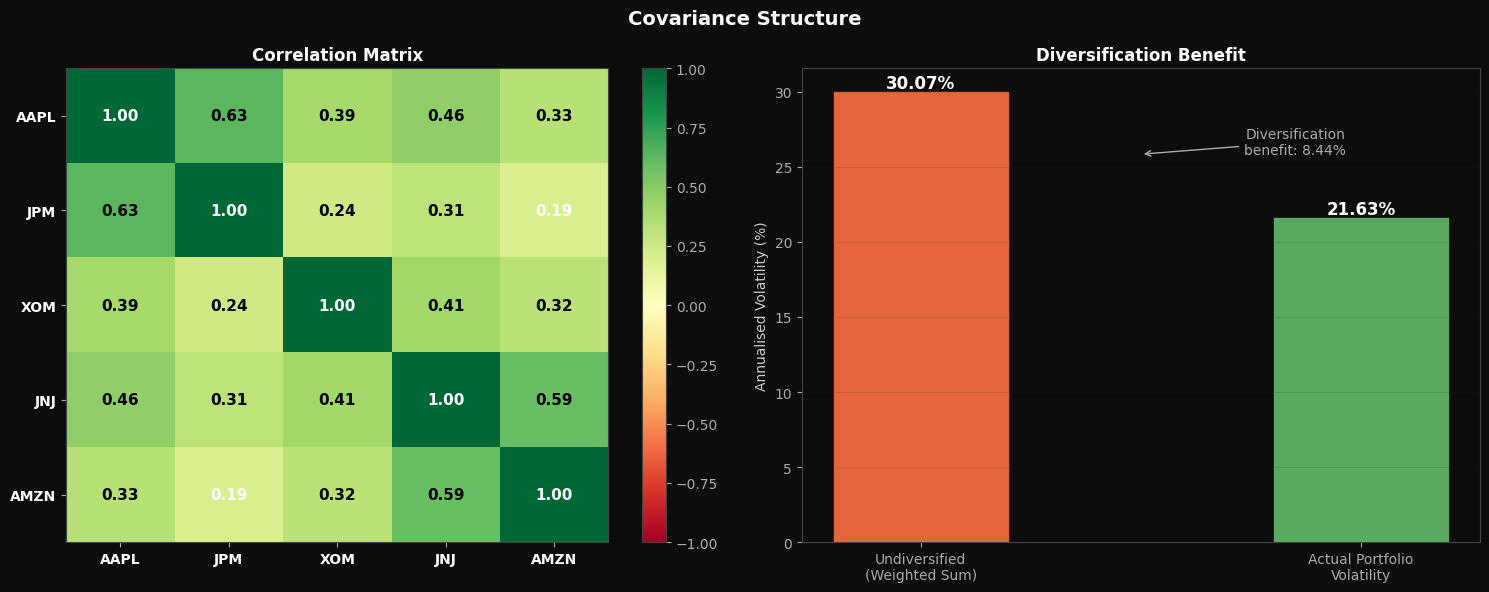

In [6]:
# ── Plot 2: Correlation heatmap + Diversification benefit ─────────────────────
corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Covariance Structure', fontsize=14, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

# Correlation heatmap
ax = axes[0]
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS, fontweight='bold', color='white')
ax.set_yticklabels(TICKERS, fontweight='bold', color='white')
ax.set_title('Correlation Matrix', fontweight='bold', color='white')
plt.colorbar(im, ax=ax)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='black' if 0.2 < abs(corr.values[i,j]) < 0.7 else 'white')

# Diversification benefit
ax2          = axes[1]
weighted_vol = np.sum(WEIGHTS * ind_vols.values) * 100
actual_vol   = port_vol * 100
diversif_ben = weighted_vol - actual_vol

bars = ax2.bar(
    ['Undiversified\n(Weighted Sum)', 'Actual Portfolio\nVolatility'],
    [weighted_vol, actual_vol],
    color=['#FF7043', '#66BB6A'], alpha=0.9,
    edgecolor='#0D0D0D', linewidth=0.5, width=0.4
)
ax2.set_title('Diversification Benefit', fontweight='bold', color='white')
ax2.set_ylabel('Annualised Volatility (%)', color='#CCCCCC')
ax2.grid(True, axis='y', alpha=0.15)
for bar, v in zip(bars, [weighted_vol, actual_vol]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.2,
             f'{v:.2f}%', ha='center', fontweight='bold',
             fontsize=12, color='white')
ax2.annotate(
    f'Diversification\nbenefit: {diversif_ben:.2f}%',
    xy=(0.5, (weighted_vol + actual_vol)/2),
    xytext=(0.85, (weighted_vol + actual_vol)/2),
    fontsize=10, ha='center', color='#AAAAAA',
    arrowprops=dict(arrowstyle='->', color='#AAAAAA')
)

plt.tight_layout()
plt.show()


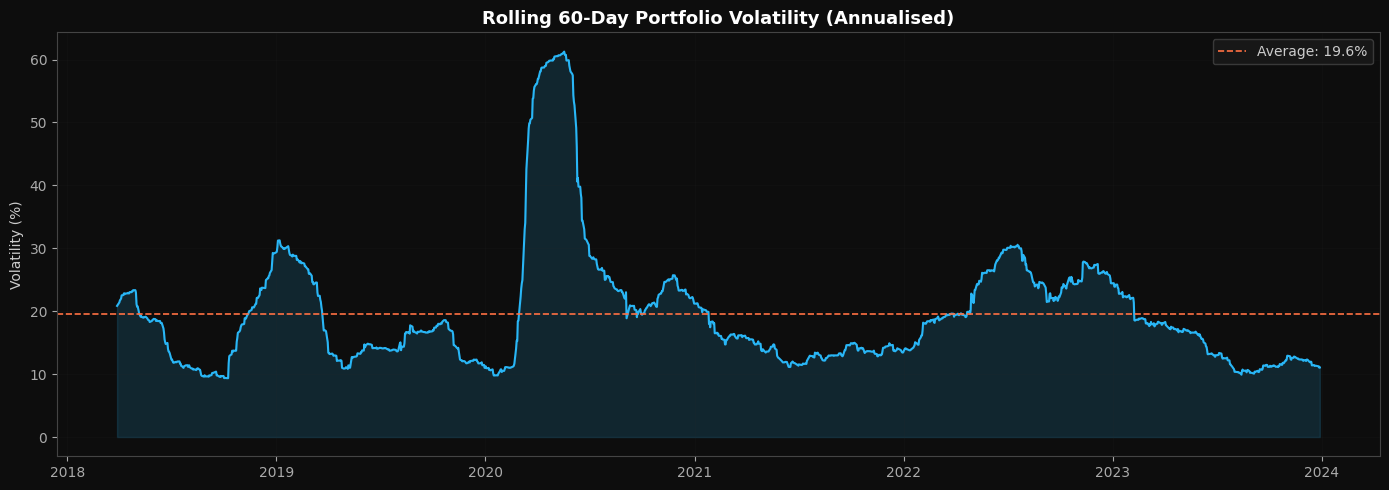

In [7]:
# ── Plot 3: Rolling portfolio volatility ──────────────────────────────────────
port_returns = (returns * WEIGHTS).sum(axis=1)
rolling_vol  = port_returns.rolling(window=60).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0D0D0D')

ax.plot(rolling_vol.index, rolling_vol.values,
        color='#29B6F6', linewidth=1.5)
ax.fill_between(rolling_vol.index, rolling_vol.values,
                alpha=0.15, color='#29B6F6')
ax.axhline(rolling_vol.mean(), color='#FF7043', linewidth=1.2,
           linestyle='--', label=f'Average: {rolling_vol.mean():.1f}%')
ax.set_title('Rolling 60-Day Portfolio Volatility (Annualised)',
             fontsize=13, fontweight='bold', color='white')
ax.set_ylabel('Volatility (%)', color='#CCCCCC')
ax.legend()
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()


## 6. Key Findings

In [8]:
print("=" * 60)
print("  PORTFOLIO RISK ATTRIBUTION — KEY FINDINGS")
print("=" * 60)
print(f"\nPortfolio Volatility (annualised) : {port_vol*100:.2f}%")
print(f"Weighted-sum Volatility           : {np.sum(WEIGHTS * ind_vols.values)*100:.2f}%")
print(f"Diversification Benefit           : {(np.sum(WEIGHTS * ind_vols.values) - port_vol)*100:.2f}%")
print("\nRisk Attribution (equal weight vs actual risk):")
for ticker in TICKERS:
    idx  = TICKERS.index(ticker)
    diff = pct_ccr[idx] - 20
    flag = '▲ Over-contributing'  if diff >  2 else \
           '▼ Under-contributing' if diff < -2 else '≈ Neutral'
    print(f"  {ticker:5s} : {pct_ccr[idx]:.1f}%  [{flag}]")
top_risk = TICKERS[np.argmax(pct_ccr)]
print(f"\nBiggest risk driver : {top_risk} ({pct_ccr[np.argmax(pct_ccr)]:.1f}%)")
print(f"Best diversifier    : {TICKERS[np.argmin(pct_ccr)]} ({pct_ccr[np.argmin(pct_ccr)]:.1f}%)")
print("=" * 60)

  PORTFOLIO RISK ATTRIBUTION — KEY FINDINGS

Portfolio Volatility (annualised) : 21.63%
Weighted-sum Volatility           : 30.07%
Diversification Benefit           : 8.44%

Risk Attribution (equal weight vs actual risk):
  AAPL  : 23.5%  [▲ Over-contributing]
  JPM   : 22.9%  [▲ Over-contributing]
  XOM   : 11.1%  [▼ Under-contributing]
  JNJ   : 21.8%  [≈ Neutral]
  AMZN  : 20.7%  [≈ Neutral]

Biggest risk driver : AAPL (23.5%)
Best diversifier    : XOM (11.1%)
